In [2]:
import numpy as np
from math import sqrt
from pprint import pprint
from sklearn import datasets
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
from sklearn import preprocessing

# Cargar y explorar los datos

In [3]:
datos = datasets.load_diabetes()
pprint(datos)
print(np.shape(datos.data))

{'DESCR': '.. _diabetes_dataset:\n'
          '\n'
          'Diabetes dataset\n'
          '----------------\n'
          '\n'
          'Ten baseline variables, age, sex, body mass index, average blood\n'
          'pressure, and six blood serum measurements were obtained for each '
          'of n =\n'
          '442 diabetes patients, as well as the response of interest, a\n'
          'quantitative measure of disease progression one year after '
          'baseline.\n'
          '\n'
          '**Data Set Characteristics:**\n'
          '\n'
          ':Number of Instances: 442\n'
          '\n'
          ':Number of Attributes: First 10 columns are numeric predictive '
          'values\n'
          '\n'
          ':Target: Column 11 is a quantitative measure of disease progression '
          'one year after baseline\n'
          '\n'
          ':Attribute Information:\n'
          '    - age     age in years\n'
          '    - sex\n'
          '    - bmi     body mass index\n'

In [4]:
# Extraer la matriz de datos "X" y la variable target "y"
X = datos.data
y = datos.target

In [5]:
# Partición EXTERNA: hold-out split 80% train - 20% test.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [6]:
# Estandarización de los datos de entrenamiento y test
standardizer = preprocessing.StandardScaler()
X_train = standardizer.fit_transform(X_train)
X_test = standardizer.transform(X_test)

In [9]:
# Métricas de evaluación.
metricas = {
  'MAE': 'neg_mean_absolute_error',
  'RMSE': make_scorer(lambda y, y_pred:
                      sqrt(mean_squared_error(y, y_pred)),
                      greater_is_better=False),
  'MAPE': make_scorer(lambda y, y_pred:
                      np.mean(np.abs((y - y_pred) / y)) * 100,
                      greater_is_better=False)}

In [10]:
# Definimos un algoritmo SVM de regresión
alg = SVR(C=10, gamma='scale', kernel='rbf')

In [11]:
# Validación y evaluación del modelo.
# en "cv = KFold(n_splits=5)" se hace un cross-validation INTERNO!! 
results = cross_validate(alg, X_train, y_train, cv = KFold(n_splits=5, shuffle=True, random_state=42), scoring = metricas)

In [12]:
# Presentación de los resultados de la evaluación.
pprint(results)

{'fit_time': array([0.00563931, 0.0030129 , 0.00552392, 0.00439453, 0.02058959]),
 'score_time': array([0.00201988, 0.0025382 , 0.00201011, 0.00400209, 0.04894114]),
 'test_MAE': array([-48.25716047, -52.04253908, -42.1232801 , -45.82429064,
       -50.35661729]),
 'test_MAPE': array([-32.92980564, -45.99818242, -37.61671569, -43.18243507,
       -44.09414842]),
 'test_RMSE': array([-57.63402295, -60.29622382, -51.85895403, -55.62016948,
       -63.93903186])}


In [13]:
# Una vez hemos optimizado los hiperparámetros en el conjunto de validación, entrenamos un nuevo modelo que contenga
# todos los datos de entrenamiento (es decir, train + validation) para evaluar el test
model = SVR(C=10, gamma='scale', kernel='rbf')
model = model.fit(X_train, y_train)

In [15]:
# Extraemos el error absoluto promedio (MAE) del conjunto de test
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print('Test results (MAE): ', mae)

Test results (MAE):  41.319671295107455


In [16]:
# También podemos extraer las predicciones para cuánto difieren los valores predichos de los reales
print('Predicciones:   ', np.round(y_pred[:10], 1))
print('Valores reales: ', y_test[:10])

Predicciones:    [149.  172.2 152.9 212.3 110.1 122.3 227.3 191.8 106.7 103.9]
Valores reales:  [219.  70. 202. 230. 111.  84. 242. 272.  94.  96.]


In [17]:
# Grafica de realidad -vs- prediccion.
def grafica_real_vs_pred(y_true, y_pred, metricas, algoritmo):
    fig, ax = plt.subplots()
    ax.scatter(y_true, y_pred, edgecolors=(0, 0, 0))
    ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=4)
    ax.set_xlabel('Valor real de la clase')
    ax.set_ylabel('Predicción')
    plt.show()

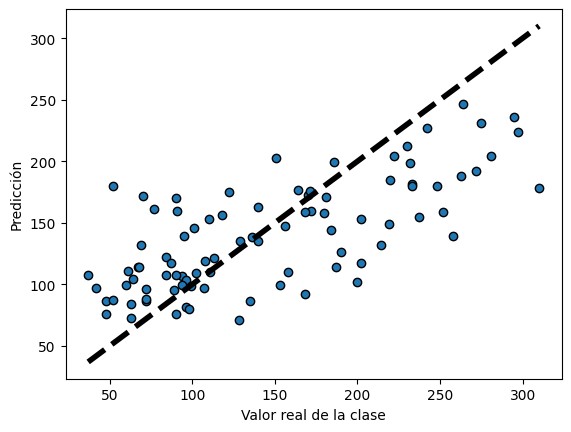

In [18]:
grafica_real_vs_pred(y_test, y_pred, metricas, model)

# GitHub 

- [https://github.com/ndadri/Cuaderno_python2](https://github.com/ndadri/Cuaderno_python2) 